# Retail Sales Performance Analysis

## Business Insights

This notebook uses the cleaned retail sales dataset to answer key business questions and generate insights for decision-making.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Load Cleaned Dataset

Load the cleaned dataset exported from the data cleaning notebook.

In [25]:
df = pd.read_csv("../data/cleaned/retail_sales_cleaned.csv")

df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,month,month_name,quarter,day_of_week
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,November,4,Friday
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,February,1,Monday
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,January,1,Friday
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,2,Sunday
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,2,Saturday


## Business Question 1

### Which product category generates the highest total revenue?

This analysis identifies which product category contributes the most revenue to the business.

In [26]:
sales_category = (
    df.groupby("product_category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

sales_category

product_category
Electronics    156905
Clothing       155580
Beauty         143515
Name: total_amount, dtype: int64

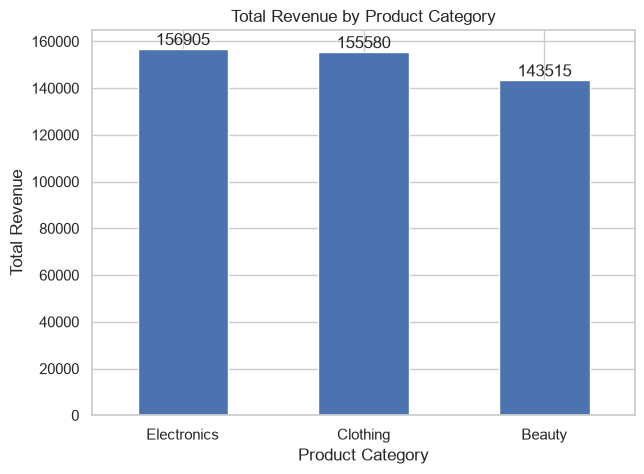

In [27]:
ax = sales_category.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

### Insight

Electronics generated the highest total revenue, reaching 156,905, followed closely by Clothing with 155,580. Beauty products recorded the lowest revenue at 143,515.

The relatively small difference between Electronics and Clothing suggests that both categories are strong revenue drivers. Maintaining sufficient inventory and marketing efforts for these two categories may help maximise future sales performance.

## Business Question 2

### Which month generated the highest total revenue?

This analysis examines monthly sales performance to identify seasonal trends and support business planning.

In [28]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("month_name")["total_amount"]
    .sum()
    .reindex(month_order)
)

monthly_sales

month_name
January      36980
February     44060
March        28990
April        33870
May          53150
June         36715
July         35465
August       36960
September    23620
October      46580
November     34920
December     44690
Name: total_amount, dtype: int64

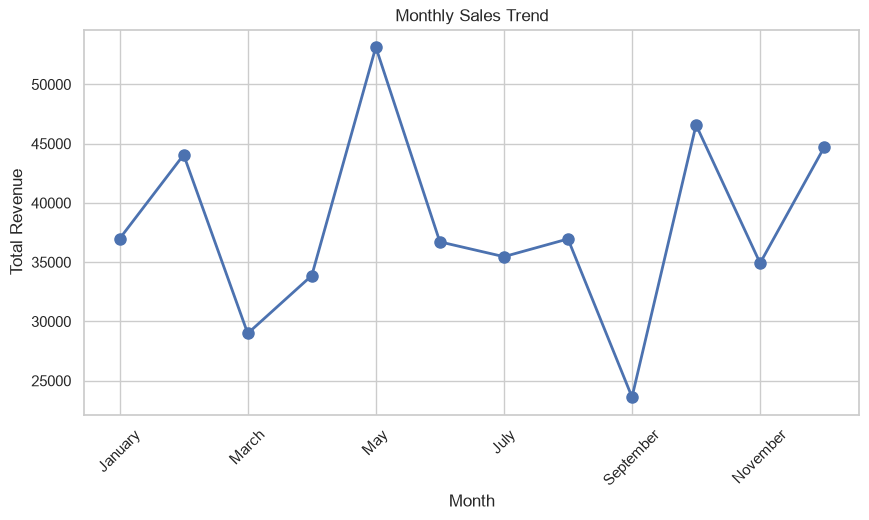

In [29]:
ax = monthly_sales.plot(
    kind="line",
    marker="o",
    linewidth=2,
    markersize=8,
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Insight

Monthly sales fluctuated throughout the year, indicating that customer purchasing behaviour varies across different months.

Sales reached the highest level in May (53,150), while September recorded the lowest revenue (23,680).

These findings suggest that the business should prepare additional inventory before peak periods and consider promotional campaigns during lower-performing months to improve sales consistency.

## Business Question 3

### Which gender contributes more total revenue?

This analysis compares total revenue generated by male and female customers to identify whether purchasing behaviour differs between customer groups.

In [30]:
sales_gender = (
    df.groupby("gender")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

sales_gender

gender
Female    232840
Male      223160
Name: total_amount, dtype: int64

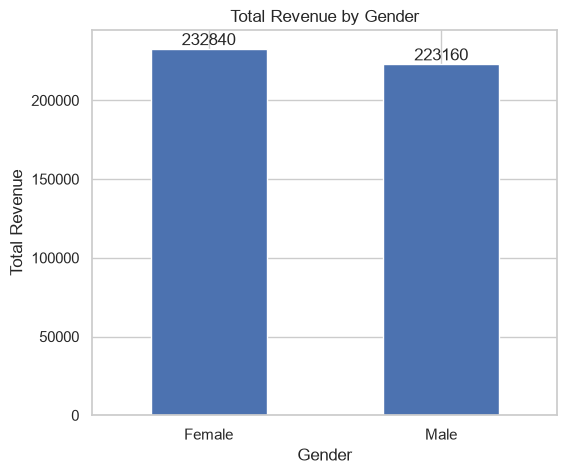

In [31]:
ax = sales_gender.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Total Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

### Insight

Female customers spent slightly more overall than male customers during the year. However, the difference is not significant, indicating that purchasing behaviour is fairly similar across both groups.

Based on these results, the business should continue developing products and marketing campaigns that appeal to both male and female customers.

# Business Question 4

## Which age group contributes the highest revenue?

This analysis examines how revenue varies across different customer age groups to identify the most valuable customer segment.

In [32]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 29, 39, 49, 59, 70],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"]
)

age_sales = (
    df.groupby("age_group")["total_amount"]
      .sum()
)

age_sales

age_group
18-29    111940
30-39     96325
40-49     93365
50-59     98340
60+       44815
Name: total_amount, dtype: int64

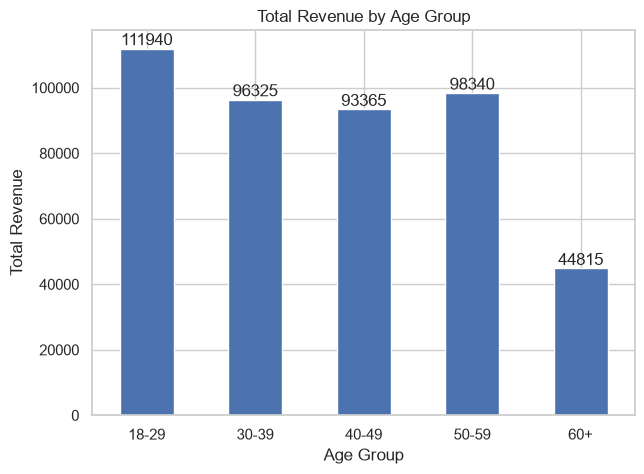

In [33]:
ax = age_sales.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Total Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

### Insight

Customers aged 18–29 generated the highest total revenue during the year.

Revenue from the 30–59 age groups remained relatively similar, while customers aged 60 and above contributed the lowest total revenue. This suggests that younger customers made a stronger contribution to overall sales in this dataset.

# Business Question 5

## Which product category has the highest average transaction value?

This analysis compares the average revenue generated per transaction across different product categories.

In [34]:
avg_sales= (
    df.groupby("product_category")["total_amount"]
    .mean()
    .sort_values(ascending=False)
)
avg_sales

product_category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: total_amount, dtype: float64

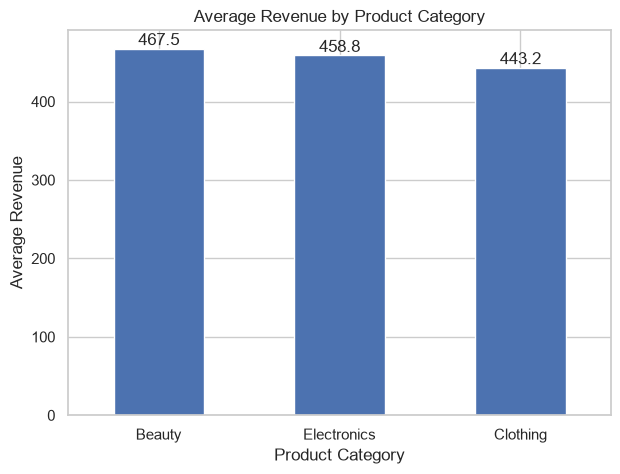

In [35]:
ax= avg_sales.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Revenue")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.show()

### Insight

Beauty products recorded the highest average revenue per transaction, followed closely by Electronics and Clothing.

The differences between categories are relatively small, indicating that customers spend a similar amount on each purchase regardless of product category.

# Business Question 6

## Which month recorded the highest number of items sold?

This analysis examines monthly sales quantity to identify changes in customer purchasing activity throughout the year.

In [36]:
monthly_quantity = (
    df.groupby("month_name")["quantity"]
      .sum()
      .reindex(month_order)
)

monthly_quantity

month_name
January      199
February     214
March        194
April        214
May          259
June         197
July         176
August       227
September    170
October      252
November     205
December     207
Name: quantity, dtype: int64

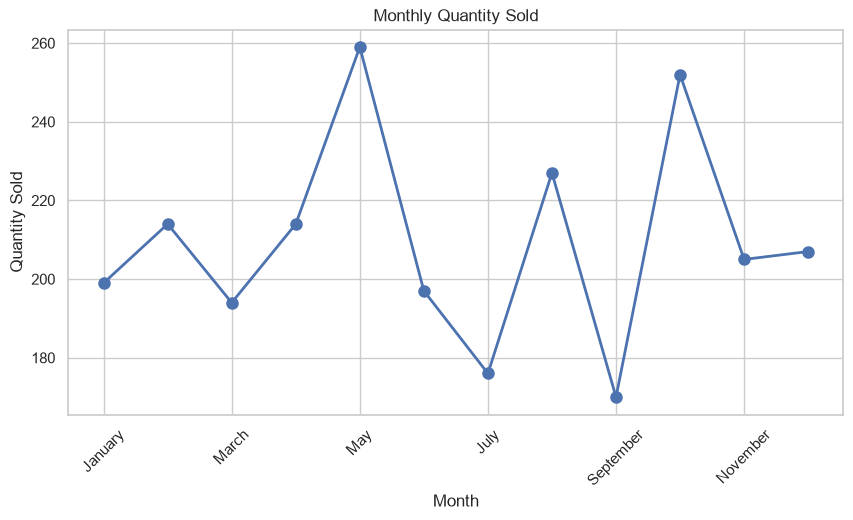

In [37]:
ax = monthly_quantity.plot(
    kind="line",
    marker="o",
    linewidth=2,
    markersize=8,
    figsize=(10,5)
)

plt.title("Monthly Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Insight

The quantity of items sold changed throughout the year, showing that customer demand was not consistent across all months.

The highest sales quantity was recorded in May, while September had the lowest number of items sold. These changes may reflect seasonal buying patterns or promotional activities during different periods of the year.

# Business Question 7

## Is there a relationship between age, quantity, price and total revenue?

A correlation analysis is used to examine how the numerical variables relate to each other and whether any strong relationships exist.

In [38]:
correlation = df[
    [
        "age",
        "quantity",
        "price_per_unit",
        "total_amount"
    ]
].corr()

correlation

,age,quantity,price_per_unit,total_amount
age,1.000000,-0.023737,-0.038423,-0.060568
quantity,-0.023737,1.000000,0.017501,0.373707
price_per_unit,-0.038423,0.017501,1.000000,0.851925
total_amount,-0.060568,0.373707,0.851925,1.000000


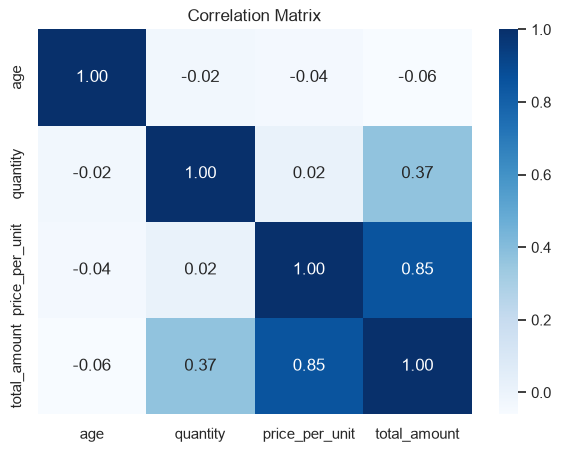

In [39]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Insight

The strongest positive relationship is between price per unit and total revenue, with a correlation of 0.85. This indicates that higher-priced products generally generate higher transaction values.

Quantity has a moderate positive relationship with total revenue, while age shows very little correlation with the other variables. Overall, customer age does not appear to have a strong influence on purchasing behaviour in this dataset.